In [40]:
import scipy
import networkx as nx #A python library that seems helpful when dealing with graphs 
import matplotlib.pyplot as plt

##fix the issues with the columns 

In [41]:
## some useful functions 

##maybe add in a feature that curves overlapping edges 
def draw_graph( graph, position = False, plot_size = (5,5)):

    plt.figure(figsize= plot_size)

    if position == False: 
        
        nx.draw(
        graph,
        with_labels=True,
        node_color="skyblue",
        node_size=600,
        font_size=8,
        font_weight = 'bold',
        edge_color="gray",)

    else: 
        nx.draw(
            graph,
            pos= position,
            with_labels=True,
            node_color="skyblue",
            node_size=600,
            font_size=8,
            font_weight = 'bold',
            edge_color="gray",)      

    plt.show()

def convert_position_to_integers (integer_Graph, cols ):
    pos_int = {}
    for node in integer_Graph.nodes():
        node_mod = node- 1
        col_idx = node_mod % cols
        row_idx = node_mod // cols
        pos_int[node] = (col_idx, -row_idx)
    return pos_int


In [42]:
def local_complementation_integers (node, Graph, show_graph = False, gridlock = False, plot_size = (3,3), position_int = pos_int):
    ##local complementation using a graph defined by integers, might work if defined by other manner but not sure
    
    # copy the graph 
    G = Graph.copy()

    #extract neighbor subgraph of node 
    neighbors = list(G.neighbors(node))
    G_sub = G.subgraph(neighbors)

    #complement the subgraph 
    G_sub_complement = nx.complement(G_sub)
    
    #delete existing edges between neighbors 
    G.remove_edges_from(G_sub.edges())
    ##Trouble shooting  print(list(G_sub.edges()))

    #add complement edges between naeighbors
    G.add_edges_from(G_sub_complement.edges())
    ##Trouble shooting  print(list(G_sub_complement.edges()) )

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G
       
    ##Trouble shooting print(neighbors)    
    

In [50]:
## making functions to perform pauli measurements/ vertex deletions and lc's for grids defined by integers 

def Z_graph_operation(vertex_to_delete, graph_int, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = pos_int): 
    
    G = graph_int.copy()
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G


def Y_graph_operation(vertex_to_delete, graph_int, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = pos_int): 
    
    G = graph_int.copy()

    #perform LC on vertex 
    G = local_complementation_integers(vertex_to_delete, G)
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

##add x operation make sure to check if pivot vertex is a neighbor 

def X_graph_operation(vertex_to_delete, graph_int, pivot = False, show_graph = False, gridlock = False, 
                      plot_size = (3,3), position_int = pos_int): 
    
    neighbors = list(graph_int.neighbors(vertex_to_delete))

    ##check to see if the vertex has any neighbors 
    if not neighbors:
        print ("vertex has no neighbors, unable to perform operation")
        return

    #pick a pivot if unspecified 
    if pivot == False:
        pivot = neighbors[0]
    
    #ensure the pivot choice is a neighbor to the desired vertex 
    if pivot not in neighbors:
        print("pivot is not a neighbor of vertex, unable to perform operation")
        return graph_int
    
    G = graph_int.copy()
    #draw_graph(G, plot_size = plot_size)


    #perform LC's on vertex and pivot  
    G = local_complementation_integers(pivot, G)
    #draw_graph(G, plot_size = plot_size)
    G = local_complementation_integers(vertex_to_delete, G)
    #draw_graph(G, plot_size = plot_size)
    G = local_complementation_integers(pivot, G)
    #draw_graph(G, plot_size = plot_size)
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G

def x_protocol_grid_integers(graph_int, ordered_repeater_line, bell_pair, show_graph = False, gridlock = False, plot_size = (3,3),
                             position_int = pos_int, show_X_measurement = False, gridlock_X = False, show_Z_measurement = False,
                             gridlock_Z = False):
    
    G = graph_int.copy()

    #itratively perform x measurements along the repeater line 
    for i in range (len(ordered_repeater_line)-2):
        
        ##print(ordered_repeater_line[i])
        ##print(i)

        #pivots are specified using the following: let V_i be the ith vertex in the repeater line. Then if X(V_1), then pivot = V_0; 
        # if x(v_{n-1}), then pivot = V_n; for any intermeidary, use an adjacent pivot on the repeater line. 
        
        if i == 0: 
            p = ordered_repeater_line[0]
        elif i == len(ordered_repeater_line)-3:
            p = ordered_repeater_line[-1]
        else :
            neighbors = list(G.neighbors(ordered_repeater_line[i+1]))
            pivots = [v for v in neighbors if v in ordered_repeater_line]

            if not pivots:
                raise ValueError(f"No repeater neighbor found for vertex {ordered_repeater_line[i+1]}")
                
            p = pivots[0]
            
        
        G = X_graph_operation(ordered_repeater_line[i+1], G, pivot = p, 
                              show_graph= show_X_measurement, gridlock= gridlock_X, plot_size= plot_size)

    #find all the neighbors of the bell pair 
    neighboring_vertices = list( G.neighbors(bell_pair[0])) + list( G.neighbors(bell_pair[1])) 
    neighboring_vertices = [v for v in neighboring_vertices if v not in bell_pair]

    
    #perform z measurements on all neighbors
    for v in neighboring_vertices: 
        G = Z_graph_operation(v, G, show_graph = show_Z_measurement, gridlock= gridlock_Z, plot_size= plot_size)

        
        #print(v)
  
    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, plot_size = plot_size)
        else:
            draw_graph(G, position_int, plot_size = plot_size)

    return G
    
    

In [ ]:
'''

#testing
# 1. Generate an m x n grid graph (e.g., 4 rows, 3 columns)
rows = 4
cols = 3

G = nx.grid_2d_graph(rows, cols)

G_int = nx.convert_node_labels_to_integers(G, first_label=1)


pos_int = convert_position_to_integers( G_int, cols)

draw_graph(G_int, pos_int, (5,5))

#testing lc, x,y,z functions 

G_int_lc = local_complementation_integers(5,G_int, gridlock= True, show_graph= True, position_int= pos_int)
G_int_z = Z_graph_operation(5, G_int, gridlock= True, show_graph = True, position_int= pos_int)
G_int_y = Y_graph_operation(5, G_int, gridlock = True, show_graph= True, position_int=pos_int)
G_int_y = X_graph_operation(5, G_int, show_graph= True, gridlock= True, position_int=pos_int)


#recreating figure 1 in Entanglement Routing and Bottlenecks in Grid Networks

draw_graph(G_int, pos_int, (3,3))
G_x_protocol_2_11 = x_protocol_grid_integers(G_int, list((2,5,8,11)), list((2,11)), show_graph= True, gridlock= True)
G_x_protocol_2_11 = x_protocol_grid_integers(G_int, list((2,1,4,7,10,11)), list((2,11)), show_graph= True, gridlock =False,
                                             show_X_measurement = False, gridlock_X = True, 
                                             show_Z_measurement = False, gridlock_Z = True,)
                                             
'''


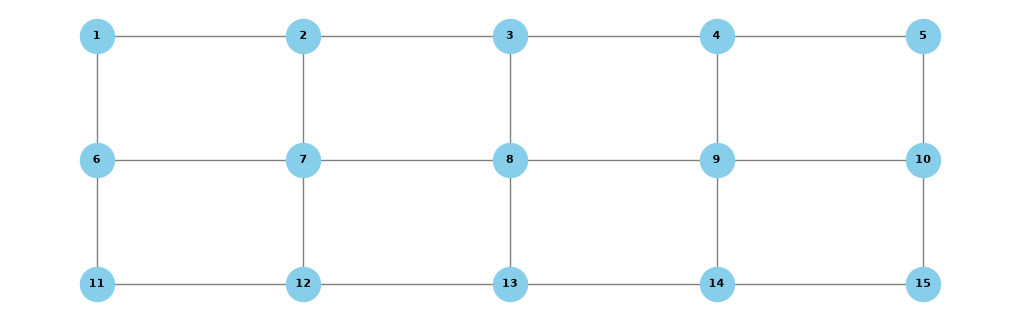

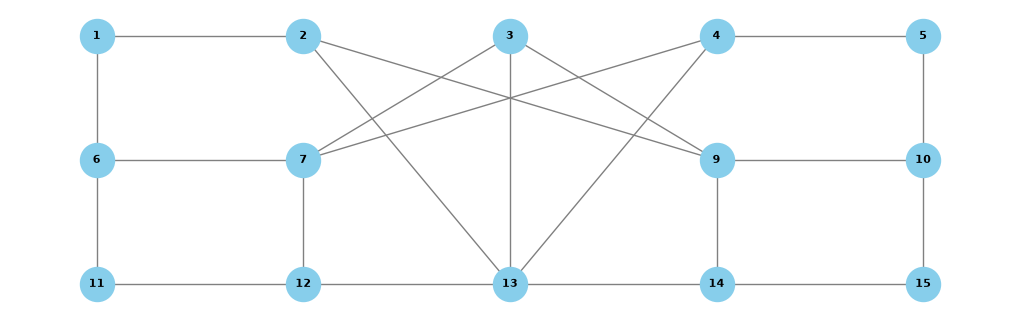

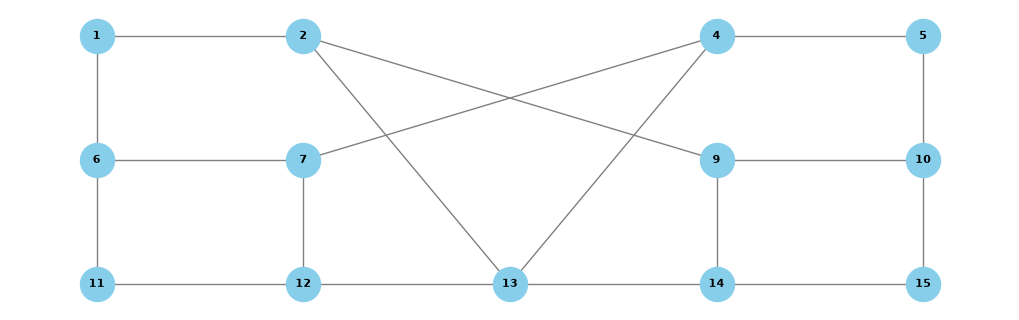

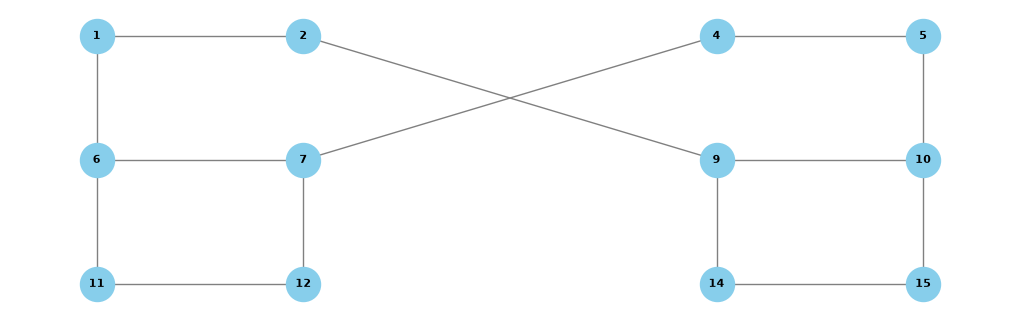

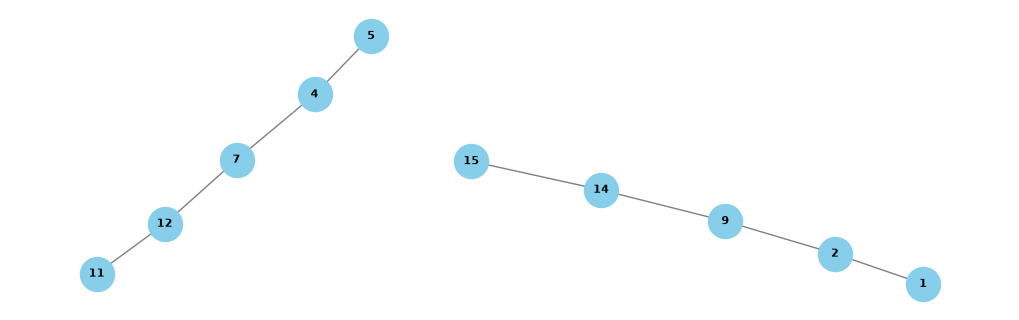

In [70]:
rows = 3
cols = 5

G = nx.grid_2d_graph(rows, cols)

G_int = nx.convert_node_labels_to_integers(G, first_label=1)


pos_int = convert_position_to_integers( G_int, cols)

draw_graph(G_int, pos_int, (10,3))


##crossing function 
G3 = X_graph_operation(8, G_int, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_int)
G3 = Z_graph_operation(3, G3, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_int)
G3 = Z_graph_operation(13, G3, show_graph= True, gridlock = True, plot_size= (10,3), position_int= pos_int)

vertices = [6,10]
for vertex in vertices: 
    G3 = Z_graph_operation(vertex, G3, show_graph= False, gridlock = True, plot_size= (10,3))
draw_graph(G3, plot_size =(10,3))